# EVRange: Real-World EV Range Prediction

End-to-end regression notebook that predicts a car's **real-world driving range (km)**
from vehicle specs, battery condition and driving/environmental conditions.

**Target column:** `real_world_range_km`

**Note on leakage:** `ARAI_certified_range_km` (the lab-test rated range) and
`energy_consumption_kWh_per_km` (which is basically derived from the target) are
**excluded** from the input features. Both are extremely strongly correlated with
the target and would let a model "cheat" instead of learning from the real drivable
conditions (weather, driving style, traffic, terrain, battery health, etc.).

**Sections:**
1. Imports
2. Load data
3. Inspect data
4. Data cleaning
5. EDA
6. Feature engineering
7. Define X / y
8. Train/test split
9. Preprocessing pipeline
10. Train baseline models
11. Evaluate & compare models
12. Hyperparameter tuning
13. Evaluate tuned models
14. Feature importance
15. best model saved here


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Modelling libraries
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Boosting libraries 
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load the EV Dataset


In [2]:
DATA_PATH = "/kaggle/input/datasets/prathameshvardhave07/evdata/india_ev_range_dataset.csv"

# Fallback for local/testing use
import os
if not os.path.exists(DATA_PATH):
    DATA_PATH = "india_ev_range_dataset.csv"

df = pd.read_csv(DATA_PATH)
df.head()


,make,model,variant,battery_capacity_kWh,battery_capacity_kWh_new,motor_power_kW,vehicle_weight_kg,drag_coefficient_Cd,frontal_area_m2,rolling_resistance_Cr,motor_efficiency_pct,ARAI_certified_range_km,avg_driving_speed_kmh,ambient_temperature_C,ac_usage,terrain_type,traffic_condition,driving_style,passengers,battery_age_years,tyre_pressure_deviation_psi,city_road_type,energy_consumption_kWh_per_km,real_world_range_km,price_lakh_INR
0,Tata,Nexon EV,Long Range,35.3,40.5,105,1610,0.34,2.4,0.0122,91,465,27.0,45.2,1,0,2,0,1,4.3,-2,Delhi,0.2504,141.00,17.5
1,Tata,Nexon EV,Long Range,40.5,40.5,105,1610,0.34,2.4,0.0120,91,465,15.0,36.7,0,0,2,1,3,0.0,0,Delhi,0.1198,338.00,17.5
2,Tata,Nexon EV,Long Range,39.3,40.5,105,1610,0.34,2.4,0.0122,91,465,20.8,32.6,1,0,1,1,3,1.0,-2,Delhi,0.1254,313.40,17.5
3,Tata,Nexon EV,Long Range,39.0,40.5,105,1610,0.34,2.4,0.0120,91,465,33.8,26.7,0,0,0,1,1,1.2,0,Delhi,0.0883,441.75,17.5
4,Tata,Nexon EV,Long Range,37.9,40.5,105,1610,0.34,2.4,0.0120,91,465,18.5,32.6,1,0,2,0,3,2.1,0,Delhi,0.1960,193.40,17.5


## 3. Inspect the Data Check shape, column names, data types, missing values and duplicate rows.

In [3]:
print("Shape (rows, columns):", df.shape)
print()
print("Column names:")
print(df.columns.tolist())


Shape (rows, columns): (7291, 25)

Column names:
['make', 'model', 'variant', 'battery_capacity_kWh', 'battery_capacity_kWh_new', 'motor_power_kW', 'vehicle_weight_kg', 'drag_coefficient_Cd', 'frontal_area_m2', 'rolling_resistance_Cr', 'motor_efficiency_pct', 'ARAI_certified_range_km', 'avg_driving_speed_kmh', 'ambient_temperature_C', 'ac_usage', 'terrain_type', 'traffic_condition', 'driving_style', 'passengers', 'battery_age_years', 'tyre_pressure_deviation_psi', 'city_road_type', 'energy_consumption_kWh_per_km', 'real_world_range_km', 'price_lakh_INR']


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7291 entries, 0 to 7290
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   make                           7291 non-null   object 
 1   model                          7291 non-null   object 
 2   variant                        7291 non-null   object 
 3   battery_capacity_kWh           7291 non-null   float64
 4   battery_capacity_kWh_new       7291 non-null   float64
 5   motor_power_kW                 7291 non-null   int64  
 6   vehicle_weight_kg              7291 non-null   int64  
 7   drag_coefficient_Cd            7291 non-null   float64
 8   frontal_area_m2                7291 non-null   float64
 9   rolling_resistance_Cr          7291 non-null   float64
 10  motor_efficiency_pct           7291 non-null   int64  
 11  ARAI_certified_range_km        7291 non-null   int64  
 12  avg_driving_speed_kmh          7291 non-null   f

In [5]:
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
make                             0
model                            0
variant                          0
battery_capacity_kWh             0
battery_capacity_kWh_new         0
motor_power_kW                   0
vehicle_weight_kg                0
drag_coefficient_Cd              0
frontal_area_m2                  0
rolling_resistance_Cr            0
motor_efficiency_pct             0
ARAI_certified_range_km          0
avg_driving_speed_kmh            0
ambient_temperature_C            0
ac_usage                         0
terrain_type                     0
traffic_condition                0
driving_style                    0
passengers                       0
battery_age_years                0
tyre_pressure_deviation_psi      0
city_road_type                   0
energy_consumption_kWh_per_km    0
real_world_range_km              0
price_lakh_INR                   0
dtype: int64


In [6]:
print("Number of fully duplicated rows:", df.duplicated().sum())


Number of fully duplicated rows: 0


In [7]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
make,7291,18,Tata,1435,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,7291,45,Nexon EV,362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
variant,7291,35,Long Range,1668,NaN,NaN,NaN,NaN,NaN,NaN,NaN
battery_capacity_kWh,7291.0,NaN,NaN,NaN,57.063503,21.639038,14.7,39.8,57.5,71.5,107.8
battery_capacity_kWh_new,7291.0,NaN,NaN,NaN,61.730462,23.235641,17.3,44.5,61.0,77.4,107.8
motor_power_kW,7291.0,NaN,NaN,NaN,192.297764,114.756511,30.0,110.0,160.0,250.0,560.0
vehicle_weight_kg,7291.0,NaN,NaN,NaN,1915.502263,459.599245,840.0,1620.0,1900.0,2170.0,2975.0
drag_coefficient_Cd,7291.0,NaN,NaN,NaN,0.291849,0.037737,0.2,0.28,0.29,0.32,0.35
frontal_area_m2,7291.0,NaN,NaN,NaN,2.414042,0.176069,1.8,2.33,2.4,2.48,2.85
rolling_resistance_Cr,7291.0,NaN,NaN,NaN,0.011578,0.000964,0.009,0.011,0.0116,0.0122,0.014


## 4. Data Cleaning


In [8]:
df_clean = df.copy()

# Drop exact duplicate rows
before = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
print(f"Dropped {before - df_clean.shape[0]} duplicate rows.")

# Fill missing numeric values with median, categorical with mode (defensive - dataset is already clean)
num_cols_all = df_clean.select_dtypes(include=[np.number]).columns
cat_cols_all = df_clean.select_dtypes(include=["object", "string"]).columns

for c in num_cols_all:
    if df_clean[c].isnull().sum() > 0:
        df_clean[c] = df_clean[c].fillna(df_clean[c].median())

for c in cat_cols_all:
    if df_clean[c].isnull().sum() > 0:
        df_clean[c] = df_clean[c].fillna(df_clean[c].mode()[0])

# Remove rows with non-physical values (e.g. range or speed <= 0)
df_clean = df_clean[df_clean["real_world_range_km"] > 0]
df_clean = df_clean[df_clean["avg_driving_speed_kmh"] > 0]

df_clean = df_clean.reset_index(drop=True)
print("Shape after cleaning:", df_clean.shape)


Dropped 0 duplicate rows.
Shape after cleaning: (7291, 25)


## 5. Exploratory Data Analysis (EDA)

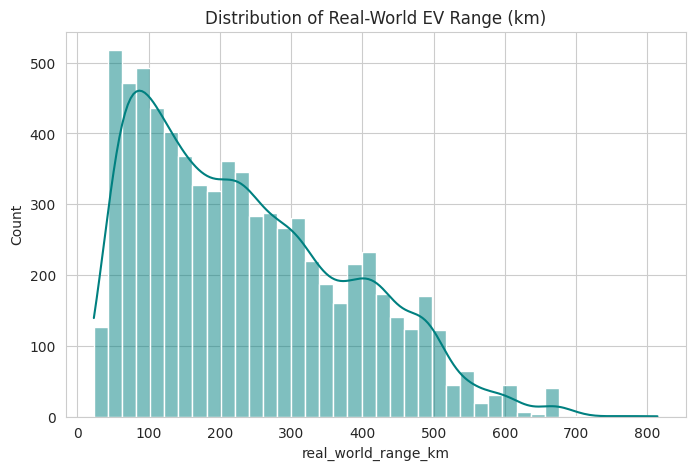

In [9]:
# Distribution of the target variable
plt.figure(figsize=(8, 5))
sns.histplot(df_clean["real_world_range_km"], kde=True, bins=40, color="teal")
plt.title("Distribution of Real-World EV Range (km)")
plt.xlabel("real_world_range_km")
plt.show()


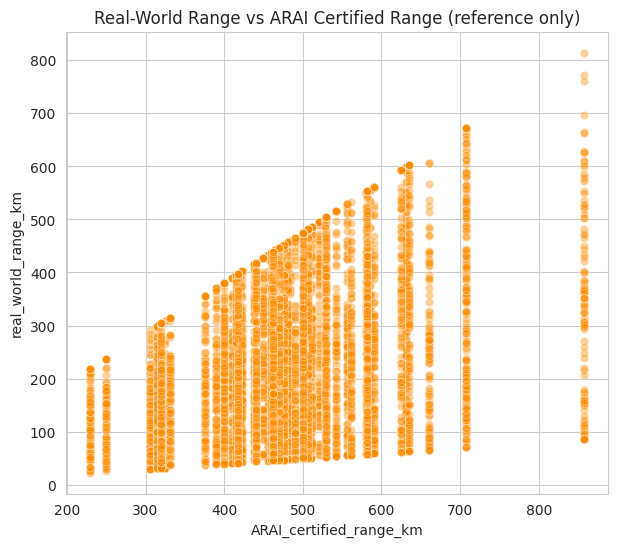

In [10]:
# Real-world range vs ARAI certified range (context only - NOT used as a feature)
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df_clean, x="ARAI_certified_range_km", y="real_world_range_km",
                 alpha=0.4, color="darkorange")
plt.title("Real-World Range vs ARAI Certified Range (reference only)")
plt.show()


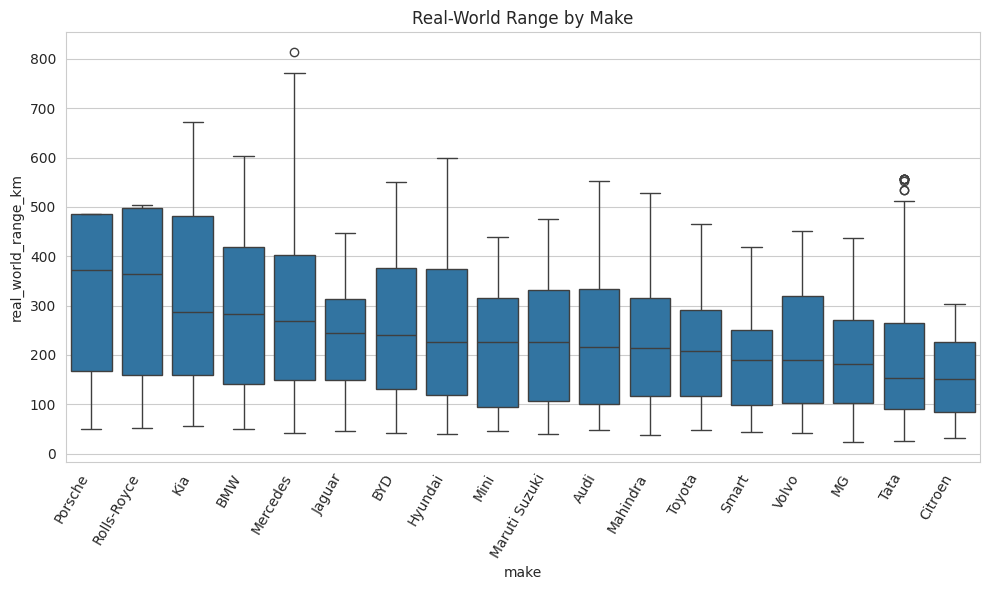

In [11]:
# Average real-world range by make
plt.figure(figsize=(10, 6))
order = df_clean.groupby("make")["real_world_range_km"].median().sort_values(ascending=False).index
sns.boxplot(data=df_clean, x="make", y="real_world_range_km", order=order)
plt.xticks(rotation=60, ha="right")
plt.title("Real-World Range by Make")
plt.tight_layout()
plt.show()


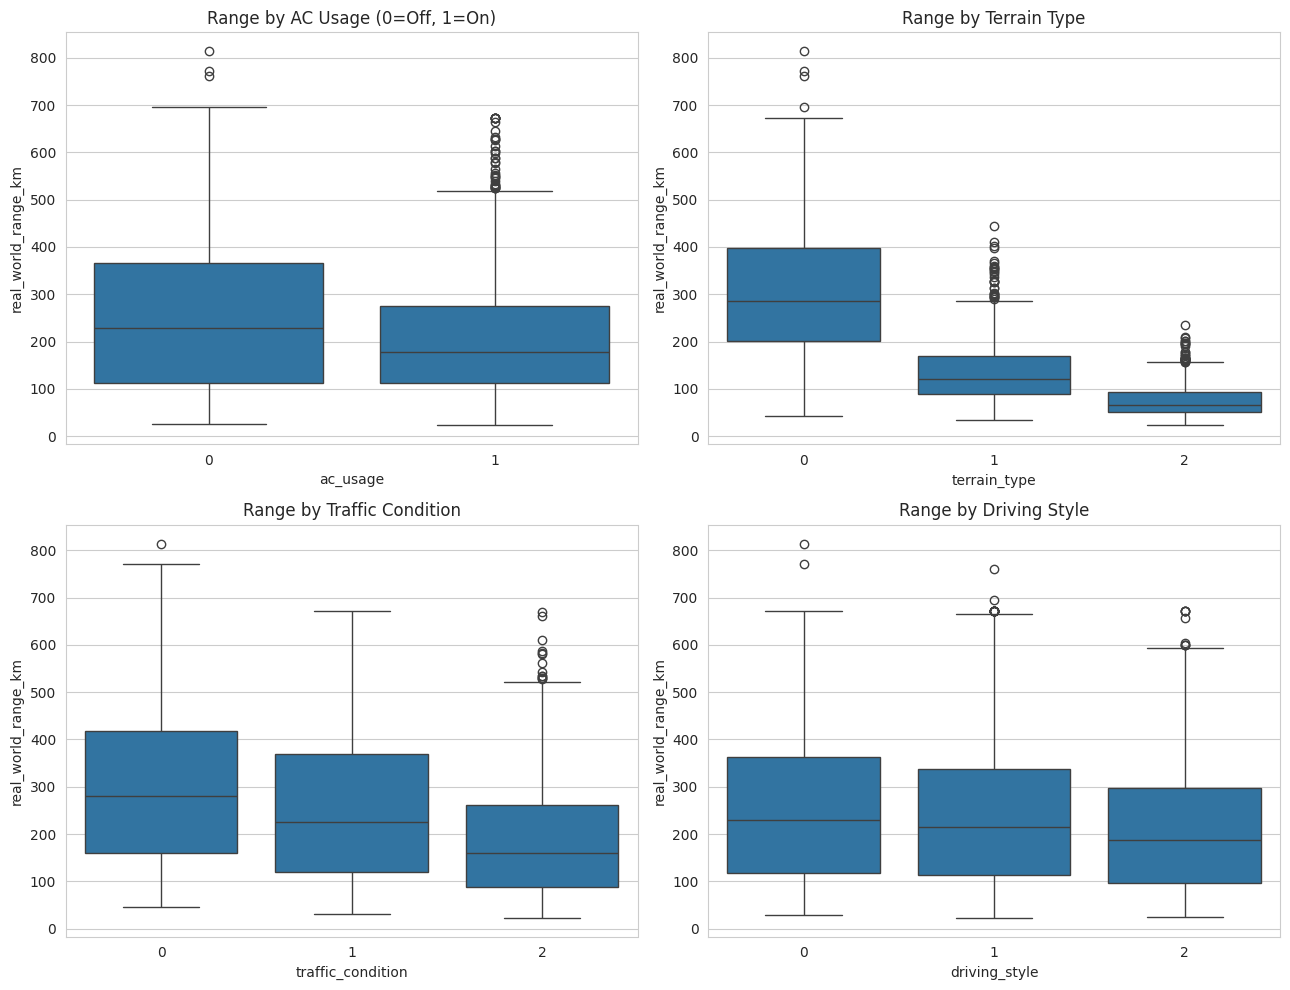

In [12]:
# Effect of driving conditions on range
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.boxplot(data=df_clean, x="ac_usage", y="real_world_range_km", ax=axes[0, 0])
axes[0, 0].set_title("Range by AC Usage (0=Off, 1=On)")

sns.boxplot(data=df_clean, x="terrain_type", y="real_world_range_km", ax=axes[0, 1])
axes[0, 1].set_title("Range by Terrain Type")

sns.boxplot(data=df_clean, x="traffic_condition", y="real_world_range_km", ax=axes[1, 0])
axes[1, 0].set_title("Range by Traffic Condition")

sns.boxplot(data=df_clean, x="driving_style", y="real_world_range_km", ax=axes[1, 1])
axes[1, 1].set_title("Range by Driving Style")

plt.tight_layout()
plt.show()


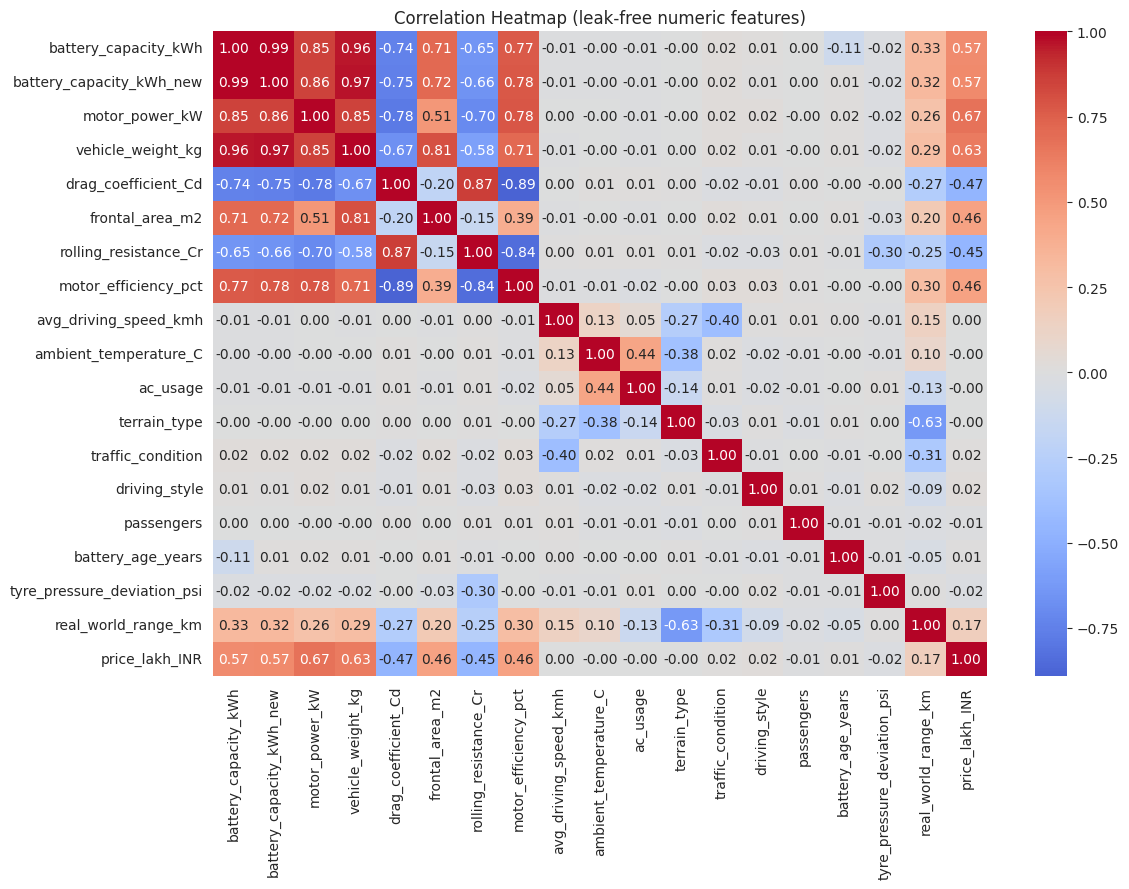

In [13]:
# Numeric feature correlation heatmap (excluding the two leaky columns)
leaky_cols = ["ARAI_certified_range_km", "energy_consumption_kWh_per_km"]
num_df = df_clean.select_dtypes(include=[np.number]).drop(columns=leaky_cols)

plt.figure(figsize=(12, 9))
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (leak-free numeric features)")
plt.tight_layout()
plt.show()


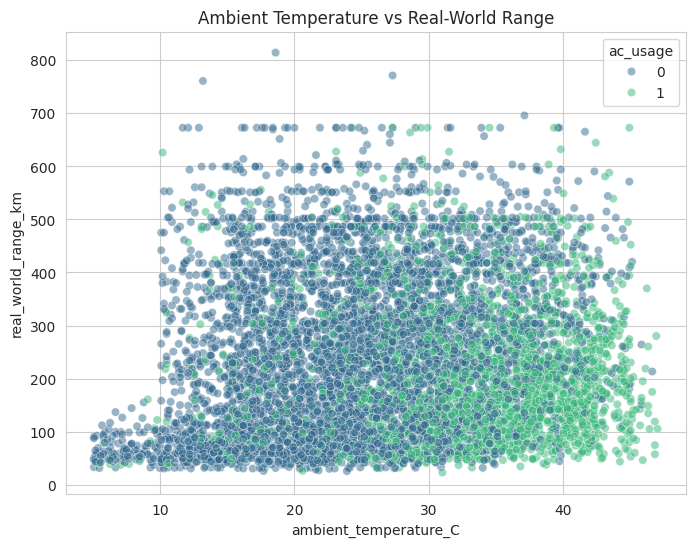

In [14]:
# Ambient temperature vs range, colored by AC usage
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_clean, x="ambient_temperature_C", y="real_world_range_km",
                 hue="ac_usage", alpha=0.5, palette="viridis")
plt.title("Ambient Temperature vs Real-World Range")
plt.show()


## 6. Feature Engineering


In [15]:
df_fe = df_clean.copy()

# Battery health = current capacity / original (new) capacity
df_fe["battery_health_pct"] = (
    df_fe["battery_capacity_kWh"] / df_fe["battery_capacity_kWh_new"]
) * 100

# Power-to-weight ratio (kW per 1000 kg)
df_fe["power_to_weight"] = df_fe["motor_power_kW"] / (df_fe["vehicle_weight_kg"] / 1000)

# Interaction between driving speed and ambient temperature
df_fe["speed_temp_interaction"] = df_fe["avg_driving_speed_kmh"] * df_fe["ambient_temperature_C"]

# Extreme temperature flag (very hot > 40C or very cold < 5C hurts EV range)
df_fe["is_extreme_temp"] = ((df_fe["ambient_temperature_C"] > 40) |
                             (df_fe["ambient_temperature_C"] < 5)).astype(int)

print("New feature columns added:")
print(["battery_health_pct", "power_to_weight", "speed_temp_interaction", "is_extreme_temp"])
df_fe[["battery_health_pct", "power_to_weight", "speed_temp_interaction", "is_extreme_temp"]].describe()


New feature columns added:
['battery_health_pct', 'power_to_weight', 'speed_temp_interaction', 'is_extreme_temp']


,battery_health_pct,power_to_weight,speed_temp_interaction,is_extreme_temp
count,7291.000000,7291.000000,7291.000000,7291.000000
mean,92.458009,93.591726,1060.742882,0.075298
std,4.293584,38.239021,918.320735,0.263890
min,84.800000,29.411765,116.480000,0.000000
25%,88.848485,69.620253,497.560000,0.000000
50%,92.459016,84.848485,731.400000,0.000000
75%,96.108949,111.922141,1150.815000,0.000000
max,100.000000,235.294118,5386.500000,1.000000


## 7. Define X and y


In [16]:
TARGET = "real_world_range_km"

leaky_features = ["ARAI_certified_range_km", "energy_consumption_kWh_per_km"]
drop_for_simplicity = ["model", "variant"]   # high-cardinality identifiers

X = df_fe.drop(columns=[TARGET] + leaky_features + drop_for_simplicity)
y = df_fe[TARGET]

categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical features:", categorical_features)
print()
print("Numerical features:", numerical_features)
print()
print("X shape:", X.shape, " | y shape:", y.shape)


Categorical features: ['make', 'city_road_type']

Numerical features: ['battery_capacity_kWh', 'battery_capacity_kWh_new', 'motor_power_kW', 'vehicle_weight_kg', 'drag_coefficient_Cd', 'frontal_area_m2', 'rolling_resistance_Cr', 'motor_efficiency_pct', 'avg_driving_speed_kmh', 'ambient_temperature_C', 'ac_usage', 'terrain_type', 'traffic_condition', 'driving_style', 'passengers', 'battery_age_years', 'tyre_pressure_deviation_psi', 'price_lakh_INR', 'battery_health_pct', 'power_to_weight', 'speed_temp_interaction', 'is_extreme_temp']

X shape: (7291, 24)  | y shape: (7291,)


## 8. Train/Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)


Train shape: (5832, 24)
Test shape : (1459, 24)


## 9. Preprocessing Pipeline


In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)


## 10. Train Multiple Regression Models


In [19]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(random_state=42),
    "Lasso": Lasso(random_state=42, max_iter=5000),
    "Random Forest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    "CatBoost": CatBoostRegressor(random_state=42, verbose=0),
}

def build_pipeline(model):
    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])

trained_pipelines = {}

for name, model in models.items():
    pipe = build_pipeline(model)
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe
    print(f"Trained: {name}")


Trained: Linear Regression
Trained: Ridge
Trained: Lasso
Trained: Random Forest
Trained: Gradient Boosting
Trained: XGBoost
Trained: CatBoost


## 11. Evaluate Every Model (MAE, RMSE, R²)

In [20]:
def evaluate_model(pipe, X_test, y_test):
    preds = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    return mae, rmse, r2

results = []
for name, pipe in trained_pipelines.items():
    mae, rmse, r2 = evaluate_model(pipe, X_test, y_test)
    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
results_df


,Model,MAE,RMSE,R2
0,CatBoost,16.116188,22.800458,0.974652
1,XGBoost,19.118167,26.739136,0.965138
2,Random Forest,22.284306,33.248807,0.946098
3,Gradient Boosting,29.915091,40.932587,0.918306
4,Linear Regression,50.879024,63.407119,0.803967
5,Ridge,50.906746,63.430496,0.803822
6,Lasso,56.354082,70.796166,0.755615


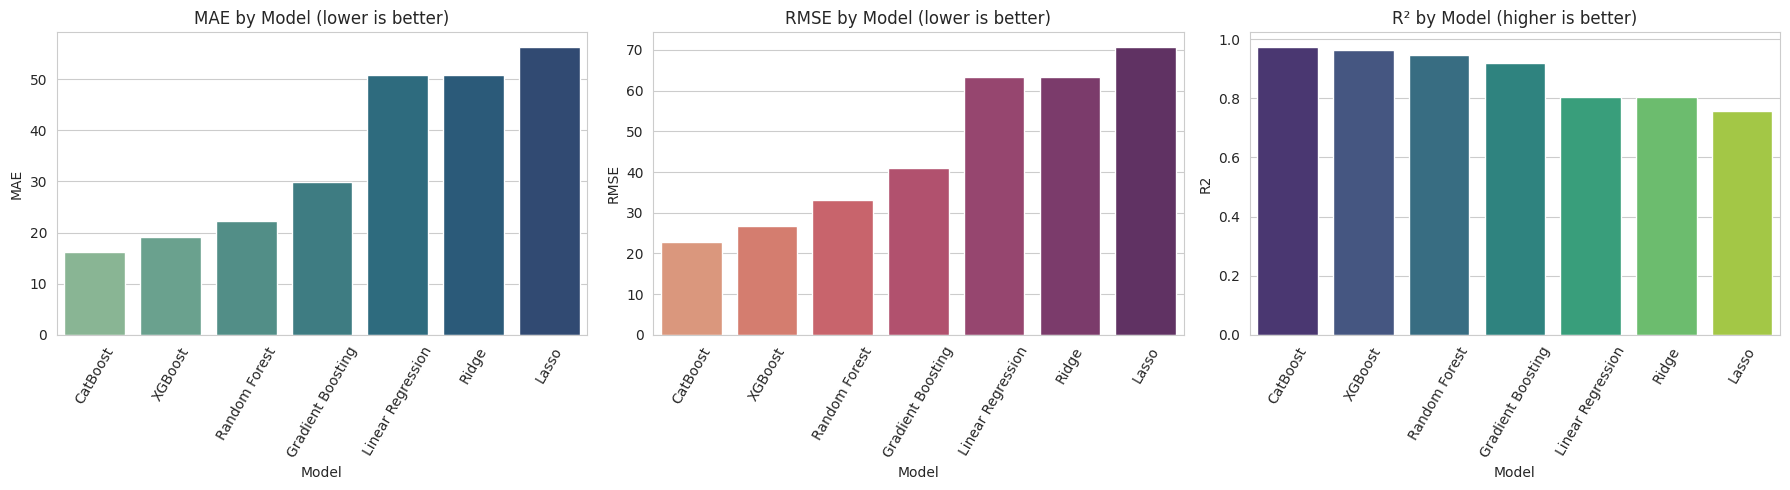

In [21]:
# Visual comparison of models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=results_df, x="Model", y="MAE", ax=axes[0], palette="crest")
axes[0].set_title("MAE by Model (lower is better)")
axes[0].tick_params(axis="x", rotation=60)

sns.barplot(data=results_df, x="Model", y="RMSE", ax=axes[1], palette="flare")
axes[1].set_title("RMSE by Model (lower is better)")
axes[1].tick_params(axis="x", rotation=60)

sns.barplot(data=results_df, x="Model", y="R2", ax=axes[2], palette="viridis")
axes[2].set_title("R\u00b2 by Model (higher is better)")
axes[2].tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()


## 12. Hyperparameter Tuning


In [22]:
param_distributions = {
    "Random Forest": {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [None, 8, 12, 16, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2", None],
    },
    "Gradient Boosting": {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [2, 3, 4, 5],
        "model__subsample": [0.7, 0.85, 1.0],
    },
    "XGBoost": {
        "model__n_estimators": [200, 300, 500],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [3, 4, 5, 6, 8],
        "model__subsample": [0.7, 0.85, 1.0],
        "model__colsample_bytree": [0.7, 0.85, 1.0],
    },
    "CatBoost": {
        "model__iterations": [300, 500, 800],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__depth": [4, 6, 8, 10],
        "model__l2_leaf_reg": [1, 3, 5, 7],
    },
}

tuned_pipelines = {}
tuning_summary = []

for name in param_distributions:
    print(f"Tuning {name} ...")
    base_pipe = build_pipeline(models[name])
    search = RandomizedSearchCV(
        estimator=base_pipe,
        param_distributions=param_distributions[name],
        n_iter=15,
        scoring="neg_root_mean_squared_error",
        cv=3,
        random_state=42,
        n_jobs=-1,
        verbose=0,
    )
    search.fit(X_train, y_train)
    tuned_pipelines[name] = search.best_estimator_
    tuning_summary.append({
        "Model": name,
        "Best CV RMSE": -search.best_score_,
        "Best Params": search.best_params_,
    })
    print(f"  Best CV RMSE: {-search.best_score_:.3f}")

tuning_df = pd.DataFrame(tuning_summary)
tuning_df


Tuning Random Forest ...
  Best CV RMSE: 37.348
Tuning Gradient Boosting ...
  Best CV RMSE: 31.335
Tuning XGBoost ...
  Best CV RMSE: 27.605
Tuning CatBoost ...
  Best CV RMSE: 24.719


,Model,Best CV RMSE,Best Params
0,Random Forest,37.347674,"{'model__n_estimators': 200, 'model__min_sampl..."
1,Gradient Boosting,31.335329,"{'model__subsample': 1.0, 'model__n_estimators..."
2,XGBoost,27.604946,"{'model__subsample': 0.7, 'model__n_estimators..."
3,CatBoost,24.719158,"{'model__learning_rate': 0.05, 'model__l2_leaf..."


## 13. Evaluate Tuned Models on the Test Set

In [23]:
tuned_results = []
for name, pipe in tuned_pipelines.items():
    mae, rmse, r2 = evaluate_model(pipe, X_test, y_test)
    tuned_results.append({"Model": f"{name} (Tuned)", "MAE": mae, "RMSE": rmse, "R2": r2})

tuned_results_df = pd.DataFrame(tuned_results).sort_values("RMSE").reset_index(drop=True)

# Combine baseline + tuned results into one comparison table
final_comparison = pd.concat([results_df, tuned_results_df], ignore_index=True)
final_comparison = final_comparison.sort_values("RMSE").reset_index(drop=True)
final_comparison


,Model,MAE,RMSE,R2
0,CatBoost (Tuned),14.978434,21.463433,0.977538
1,CatBoost,16.116188,22.800458,0.974652
2,XGBoost (Tuned),17.464195,24.868222,0.969846
3,XGBoost,19.118167,26.739136,0.965138
4,Gradient Boosting (Tuned),20.962388,29.144090,0.958585
5,Random Forest,22.284306,33.248807,0.946098
6,Random Forest (Tuned),22.464227,33.423398,0.945530
7,Gradient Boosting,29.915091,40.932587,0.918306
8,Linear Regression,50.879024,63.407119,0.803967
9,Ridge,50.906746,63.430496,0.803822


## 14. Feature Importance

Shown for the tree-based models, which expose `feature_importances_`.


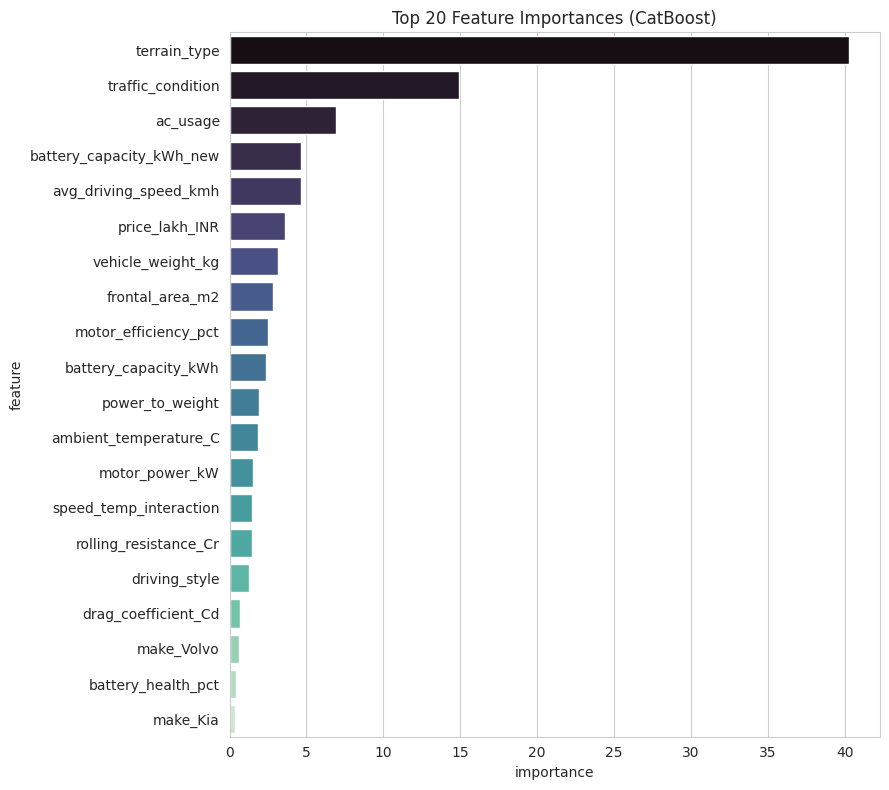

,feature,importance
11,terrain_type,40.274499
12,traffic_condition,14.905034
10,ac_usage,6.899763
1,battery_capacity_kWh_new,4.669978
8,avg_driving_speed_kmh,4.639631
17,price_lakh_INR,3.592104
3,vehicle_weight_kg,3.119646
5,frontal_area_m2,2.825090
7,motor_efficiency_pct,2.523957
0,battery_capacity_kWh,2.365261


In [24]:
def get_feature_names(preprocessor):
    num_names = numerical_features
    cat_names = list(
        preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
    )
    return num_names + cat_names

# Pick a tuned tree-based model to inspect (falls back to baseline if tuning skipped)
importance_model_name = tuning_df.sort_values("Best CV RMSE").iloc[0]["Model"]
best_tree_pipe = tuned_pipelines[importance_model_name]

feature_names = get_feature_names(best_tree_pipe.named_steps["preprocessor"])
importances = best_tree_pipe.named_steps["model"].feature_importances_

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
}).sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(9, 8))
sns.barplot(data=fi_df, x="importance", y="feature", palette="mako")
plt.title(f"Top 20 Feature Importances ({importance_model_name})")
plt.tight_layout()
plt.show()

fi_df


## Saving the best performed model


In [25]:
import joblib
import os

final_model = tuned_pipelines["CatBoost"]

os.makedirs("models", exist_ok=True)

# Save complete pipeline
joblib.dump(
    final_model,
    "models/ev_range_catboost.pkl"
)

print("Final CatBoost model saved successfully.")

Final CatBoost model saved successfully.
